# Somerville processed permits — summary & outlier triage

Reads `data/processed/ma/somerville/joined_data.csv` (the output of
`make process-somerville`) and answers two questions:

**a)** Does the processed table look right — did the residential filter, the project-type
regexes, and the assessor join do what they were supposed to?

**b)** Which rows are outliers, and where should the cutoffs go?

Sections 1–5 are read-only diagnostics. **Section 6 is the workbench**: one `PARAMS`
dict of thresholds, and every downstream cell reports what those thresholds actually
cost you. Tune `PARAMS`, re-run from there down, and look at the numbers again.

A note on shape, because it drives most of what follows: one row is **one permit**, not
one building. The assessor attributes are joined on, so a 125-unit building contributes
its `res_area` once per permit filed against it. Anything that looks like a fat tail in
`res_area` is usually a big building with a lot of permits, not a bad value.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 90)

# Validated categorical slots, assigned in fixed order and never cycled.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED = "#0b0b0b", "#52514e"

plt.rcParams.update({
    "figure.figsize": (9, 3.4),
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d8d7d2",     # recessive grid, behind the marks
    "grid.linewidth": 0.6,
    "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlelocation": "left",
    "axes.titlesize": 11,
    "axes.labelcolor": MUTED,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "lines.linewidth": 2,
})

CSV = Path("../data/processed/ma/somerville/joined_data.csv")

# One boolean column per project type. Independent: a permit can carry several
# flags or none, and all-false is the residual "no equipment named" bucket.
# Mirrors PROJECT_TYPE_PATTERNS order in the pipeline.
FLAGS = ["solar_pv", "heat_pumps", "ev_charger", "electrical_panel", "other_hvac"]

In [2]:
df = pd.read_csv(CSV, low_memory=False)
df["application_date"] = pd.to_datetime(df["application_date"], errors="coerce")
df[FLAGS] = df[FLAGS].astype(bool)

# A compact label for display only -- "solar_pv+electrical_panel", or "untagged".
# Never filter on this; filter on the boolean columns.
df["flag_label"] = (
    df[FLAGS].apply(lambda r: "+".join(c for c in FLAGS if r[c]), axis=1).replace("", "untagged")
)
n_flags = df[FLAGS].sum(axis=1)

# NB: `style` is a real column here and `df.style` is the pandas Styler.
# Always reach for it as df["style"].
print(f"{len(df):,} rows x {df.shape[1]} columns from {CSV}")
print(f"date range: {df['application_date'].min():%Y-%m-%d} to {df['application_date'].max():%Y-%m-%d}")
df.head(3)

62,050 rows x 30 columns from ../data/processed/ma/somerville/joined_data.csv
date range: 2014-02-13 to 2026-09-03


,application_number,application_date,application_type,application_subtype,project_description,solar_pv,heat_pumps,ev_charger,electrical_panel,other_hvac,address,apn,parcel_key,parcel_prefix,latitude,longitude,contractor_company_name,applicant_company_name,match_level,assess_records,loc_id,prop_id,year_built,res_area,num_rooms,style,use_code,stories,units,flag_label
0,E14-001179,2014-11-03,Electrical Permit,Residential,wire bathrooms,False,False,False,False,False,"297 ALEWIFE BROOK PKWY, SOMERVILLE MASSACHUSETTS",004-B-00044-000000,4-B-44,4-B-44,42.409577,-71.130242,Robert Nazzaro,Robert Nazzaro,unit,1.0,F_756023_2974493,4_B_44,1920.0,2060.0,11.0,2-Decker,1040,2.0,0.0,untagged
1,E14-001180,2014-11-03,Electrical Permit,Residential,Installing 24 PV solar panels on roof. 5.98KW system.,True,False,False,False,False,"35 GORDON ST, SOMERVILLE MASSACHUSETTS 02144",003-B-00024-000000,3-B-24,3-B-24,42.412717,-71.128635,"Roof Diagnostics Solar of Mass, LLC/NRG Home Solar","Roof Diagnostics Solar of Mass, LLC",unit,1.0,F_756454_2975643,3_B_24,1930.0,3130.0,10.0,Two Family,1040,2.5,0.0,solar_pv
2,B14-001250,2014-11-03,Building Permit,Residential Other,Replace decking boards on existing deck. Extend existing deck. ( 7' x 9' extension) re...,False,False,False,False,False,"17 CHERRY ST, SOMERVILLE MASSACHUSETTS 02144",030-E-00016-000000,30-E-16,30-E-16,42.389956,-71.115570,Absolute Construction Co.,Absolute Construction Co.,unit,1.0,F_760014_2967359,30_E_16,1900.0,2057.0,10.0,2 Fam Conv,1040,1.8,0.0,untagged


## 1. Completeness

Two different kinds of "missing" live in this table and they need separating:

- **NaN** — the join found nothing, or the source cell was blank.
- **0** — the assessor wrote a zero. In the MassGIS CAMA extract a zero in `res_area`,
  `num_rooms`, or `units` is a *missing-value sentinel*, not a measurement. A house with
  0 rooms does not exist; a row with `res_area == 0` is an unpopulated record.

Anything with a high zero rate is a column you should not filter on, and probably should
not model on either.

In [3]:
def completeness(frame: pd.DataFrame) -> pd.DataFrame:
    """Per-column null rate, zero rate (numerics), and cardinality."""
    rows = []
    for col in frame.columns:
        s = frame[col]
        # Bools are numeric to pandas, but "zero" on a flag column just means
        # False and is already covered by its count -- so skip them.
        numeric = pd.api.types.is_numeric_dtype(s) and not pd.api.types.is_bool_dtype(s)
        zero = (s == 0).sum() if numeric else np.nan
        rows.append({
            "dtype": str(s.dtype),
            "null": s.isna().sum(),
            "null_%": round(s.isna().mean() * 100, 2),
            "zero": zero,
            "zero_%": round(zero / len(frame) * 100, 2) if zero == zero else np.nan,
            "n_unique": s.nunique(dropna=True),
        })
    return pd.DataFrame(rows, index=frame.columns)

completeness(df)

,dtype,null,null_%,zero,zero_%,n_unique
application_number,str,0,0.00,NaN,NaN,62050
application_date,datetime64[us],6,0.01,NaN,NaN,4308
application_type,str,0,0.00,NaN,NaN,4
application_subtype,str,0,0.00,NaN,NaN,9
project_description,str,18,0.03,NaN,NaN,50624
solar_pv,bool,0,0.00,NaN,NaN,2
heat_pumps,bool,0,0.00,NaN,NaN,2
ev_charger,bool,0,0.00,NaN,NaN,2
electrical_panel,bool,0,0.00,NaN,NaN,2
other_hvac,bool,0,0.00,NaN,NaN,2


**What to look at here**

- `contractor_company_name` is empty on roughly a third of rows — by design. Gas Fitting
  and Plumbing permits never populate it; `applicant_company_name` is the only party on
  those. Use a coalesce of the two, not the contractor column alone.
- `stories` is missing on ~27% of rows because the pipeline maps the assessor's `0`
  sentinel to NA. That is correct behaviour, but it means `stories` is unusable as a
  filter key — you would drop a quarter of the data for a reason unrelated to the permit.
- `units` is ~0 on nearly every row. It is not a building unit count in this extract.
  Treat it as unpopulated and ignore it.

## 2. Permit-side sanity

Before touching the assessor attributes: is the permit half of the table the set of rows
we meant to keep? The pipeline filters to four trade families and to a `Residential`
occupancy class parsed out of the subtype string, so both of those are worth confirming.

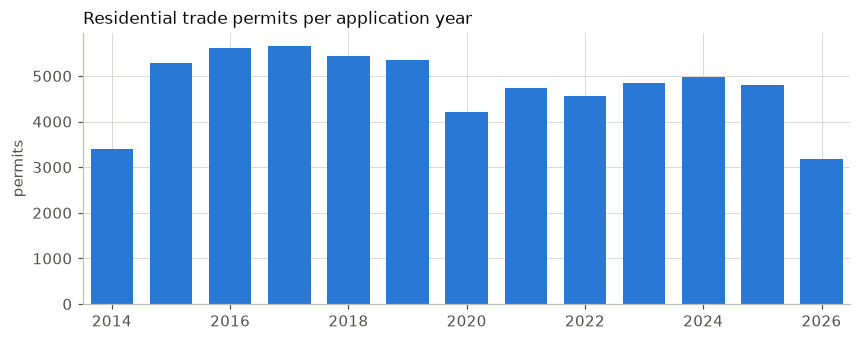

application_date,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0,2023.0,2024.0,2025.0,2026.0
permits,3398,5286,5610,5659,5447,5352,4202,4744,4569,4835,4971,4798,3173


In [4]:
by_year = df["application_date"].dt.year.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(by_year.index, by_year.values, color=BLUE, width=0.72)
ax.set_title("Residential trade permits per application year")
ax.set_ylabel("permits")
ax.margins(x=0.01)
plt.show()

by_year.to_frame("permits").T

The series is flat at ~4,500–5,600/yr with two explicable dents: 2020 (COVID) and the
first and last years, which are partial. **2026 is a partial year** — the extract was
pulled 2026-09-03. Any per-year rate you compute needs 2026 either annualized or dropped;
it is not a real decline.

2014 is also suspiciously low for a full year, which usually means the city's system
went live mid-year. Check the earliest months before you treat 2014 as a complete
baseline.

In [5]:
early = df[df["application_date"] < "2015-01-01"]
early_by_month = early["application_date"].dt.to_period("M").value_counts().sort_index()
print("Permits per month in the first year of the extract:")
print(early_by_month.to_string())

Permits per month in the first year of the extract:
application_date
2014-02      1
2014-03     33
2014-04     85
2014-05    214
2014-06    494
2014-07    468
2014-08    414
2014-09    514
2014-10    474
2014-11    360
2014-12    341
Freq: M


In [6]:
pd.crosstab(df["application_type"], df["application_subtype"]).replace(0, "").T

application_type,Building Permit,Electrical Permit,Gas Fitting,Plumbing Permit
application_subtype,,,,
Residential,,18392,,
Residential - Existing,,,8130,9322
Residential - New,,,547,660
Residential Addition,563,,,
Residential Alteration,3847,,,
Residential New Construction,572,,,
Residential Other,3612,,,
Residential Renovation,4242,,,
Residential Repair,12163,,,


Every subtype in the table should read as residential. If a `Commercial` or `Institutional`
value appears above, the first-word parse in `filter_residential` has a case it does not
handle and the fix belongs in the pipeline, not in an outlier filter here.

In [7]:
# Structural integrity checks -- each of these should be 0 or explainable.
checks = {
    "duplicate application_number": df["application_number"].duplicated().sum(),
    "null application_date": df["application_date"].isna().sum(),
    "null project_description": df["project_description"].isna().sum(),
    "null apn": df["apn"].isna().sum(),
    "null lat/lon": df["latitude"].isna().sum(),
    "no company on either column": (
        df["contractor_company_name"].isna() & df["applicant_company_name"].isna()
    ).sum(),
    "date in the future": (df["application_date"] > pd.Timestamp.today()).sum(),
}
pd.Series(checks, name="rows").to_frame()

,rows
duplicate application_number,0
null application_date,6
null project_description,18
null apn,50
null lat/lon,74
no company on either column,2677
date in the future,0


## 3. Project-type flag audit

The project types are **five independent boolean columns**, not one label. A permit that
upgrades the service *and* hangs an EV charger flags both; a permit whose description
names no equipment at all ("renovation", "rewire 3 units") flags none. That is the
residual bucket, and it is the majority of the table.

Two consequences for this audit, both of which the old enum hid:

- **Nothing shadows anything.** Under first-match-wins, an earlier `solar_pv` rule
  absorbed "42 solar panels" before any panel rule saw it. Now every pattern is evaluated
  against every row, so precision rests entirely on the patterns themselves. Section 3.3
  probes exactly that.
- **The columns are not mutually exclusive**, so counts sum to more than the rows they
  cover. Anything that treats them as a partition -- a pie chart, a share-of-total, a
  groupby -- is wrong. Use per-flag rates against the full row count.

The one deliberate dependency: `other_hvac` is masked to exclude `heat_pumps`, because a
mini-split *is* a condenser and an air handler and would otherwise fire both.

### 3.1 How often does each flag fire?

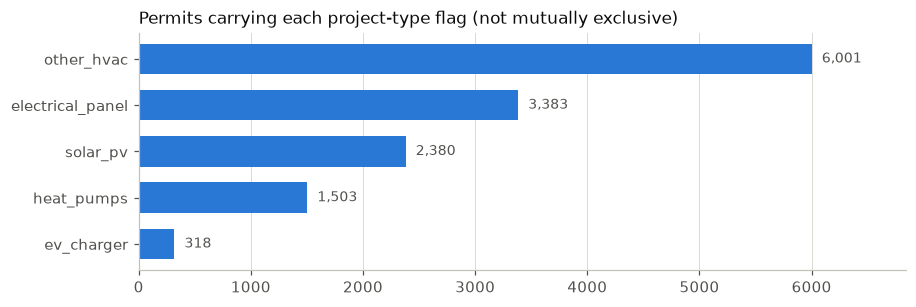

,permits,% of all rows
other_hvac,6001,9.67
electrical_panel,3383,5.45
solar_pv,2380,3.84
heat_pumps,1503,2.42
ev_charger,318,0.51


In [8]:
counts = df[FLAGS].sum().sort_values()
rate = (counts / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.barh(counts.index, counts.values, color=BLUE, height=0.66)
for label, v in zip(counts.index, counts.values):
    ax.text(v + counts.max() * 0.015, label, f"{v:,}", va="center", fontsize=9, color=MUTED)
ax.set_title("Permits carrying each project-type flag (not mutually exclusive)")
ax.set_xlim(0, counts.max() * 1.14)
ax.grid(axis="y", visible=False)
plt.show()

pd.DataFrame({"permits": counts, "% of all rows": rate}).sort_values("permits", ascending=False)

In [9]:
# How many flags does a row carry? Counts must be read against this, not summed.
dist = n_flags.value_counts().sort_index()
pd.DataFrame({
    "rows": dist,
    "% of table": (dist / len(df) * 100).round(2),
}).rename_axis("flags on the row")

,rows,% of table
flags on the row,,
0,48923,78.84
1,12679,20.43
2,438,0.71
3,10,0.02


Roughly four rows in five carry **no flag**. That is expected and is not a failure of the
rules -- most residential permits are kitchens, bathrooms, roofs, and decks, and no
pattern targets those. The number to interrogate is not the size of the untagged bucket;
it is whether the five real flags are *complete* (3.3) and *clean* (3.4).

Multi-flag rows are a small but real population. They are the reason this schema changed:
under the enum every one of them was silently assigned to whichever rule happened to run
first, and the other trade on the permit vanished.

### 3.2 Which flags co-occur?

The diagonal is each flag's own total; off-diagonal cells are permits carrying both. This
is the table the enum could not produce.

In [10]:
co = pd.DataFrame(
    {a: {b: int((df[a] & df[b]).sum()) for b in FLAGS} for a in FLAGS},
    index=FLAGS,
)[FLAGS]
print("Co-occurrence counts (diagonal = flag total):")
print(co.to_string())

# Same thing as a rate: of the rows carrying the ROW flag, what % also carry the column's?
# Mask the diagonal rather than writing into .values -- that array is read-only.
pct = (co.div(np.diag(co), axis=0) * 100).round(1)
pct = pct.mask(np.eye(len(FLAGS), dtype=bool))
print("\n% of the row flag's permits that also carry the column flag:")
print(pct.to_string(na_rep="--"))

Co-occurrence counts (diagonal = flag total):
                  solar_pv  heat_pumps  ev_charger  electrical_panel  other_hvac
solar_pv              2380           1           4                37           0
heat_pumps               1        1503          11               132           0
ev_charger               4          11         318               114           4
electrical_panel        37         132         114              3383         165
other_hvac               0           0           4               165        6001

% of the row flag's permits that also carry the column flag:
                  solar_pv  heat_pumps  ev_charger  electrical_panel  other_hvac
solar_pv                --         0.0         0.2               1.6         0.0
heat_pumps             0.1          --         0.7               8.8         0.0
ev_charger             1.3         3.5          --              35.8         1.3
electrical_panel       1.1         3.9         3.4                --         4.9
o

In [11]:
# Invariants the pipeline promises. Both should be exactly 0.
checks = {
    "other_hvac AND heat_pumps (masked in pipeline)": int((df["other_hvac"] & df["heat_pumps"]).sum()),
    "flag column with a null": int(df[FLAGS].isna().sum().sum()),
}
pd.Series(checks, name="rows").to_frame()

,rows
other_hvac AND heat_pumps (masked in pipeline),0
flag column with a null,0


The pairs worth understanding:

- **`electrical_panel` co-occurs with everything.** It is the hub of this table, and that
  is real rather than a bug: a heat pump, an EV charger, and a solar array all commonly
  require a service upgrade, and the permit describes both jobs. This is precisely the
  signal the enum destroyed.
- **`solar_pv` x `other_hvac` should be ~0.** Solar and furnaces are unrelated trades;
  a nonzero cell would mean one pattern is picking up the other's vocabulary.
- **`ev_charger` x `electrical_panel`** is the highest-rate pair by a distance. Sensible --
  a charger is a 40-50A circuit that frequently forces a panel upgrade -- but it also
  means you cannot count "EV work" and "panel work" as separate populations and add them.

### 3.3 Recall probe: what did the rules miss?

For each flag, a deliberately *looser* pattern is run against the **untagged** rows. Hits
are candidate false negatives -- descriptions that name the equipment in words the
production regex does not cover.

In [12]:
PROBES = {
    "heat_pumps":       r"heat pump|heatpump|mini.?split|ductless|air.?source|\bashp\b|\bvrf\b",
    "solar_pv":         r"solar|photovolt|\bpv\b|inverter|micro.?inverter",
    "ev_charger":       r"\bev\b|electric vehicle|\bevse\b|car charger|charging station|wall connector",
    "electrical_panel": r"\bpanel\b|\bamp\b|service upgrade|load cent|breaker|\bmeter\b",
    "other_hvac":       r"furnace|boiler|hvac|air.?condition|condens|\bac\b|duct|\brtu\b",
    "battery_storage":  r"battery|\bess\b|powerwall|energy storage",   # still no rule for this
}

untagged = df[n_flags == 0]
desc = untagged["project_description"].fillna("").str.lower()

probe_rows = []
for label, pat in PROBES.items():
    hits = desc.str.contains(pat, regex=True, na=False)
    probe_rows.append({
        "probe": label,
        "hits_in_untagged": int(hits.sum()),
        "% of untagged": round(hits.mean() * 100, 2),
        "rows the flag has": int(df[label].sum()) if label in df.columns else 0,
    })
pd.DataFrame(probe_rows).set_index("probe")

,hits_in_untagged,% of untagged,rows the flag has
probe,,,
heat_pumps,2,0.00,1503
solar_pv,7,0.01,2380
ev_charger,0,0.00,318
electrical_panel,1242,2.54,3383
other_hvac,190,0.39,6001
battery_storage,63,0.13,0


In [13]:
# Eyeball the misses for whichever probe looks worst above.
PROBE = "electrical_panel"

hits = desc.str.contains(PROBES[PROBE], regex=True, na=False)
print(f"{PROBE}: {hits.sum():,} candidate misses among untagged rows\n")
print(untagged.loc[hits, "project_description"].sample(min(15, int(hits.sum())), random_state=0).to_string())

electrical_panel: 1,242 candidate misses among untagged rows

52300                                                      Add 1 meter for unit 2 and public meter
5938                                                  Removal of meter and lights for vinyl siding
9180                                        Remove and install back meter for siding installation.
45452                                           Remove and re-install meter for siding replacement
878            pull meter for new siding, remove lights and outlets and reinstall after new siding
57055    Remove (chest high) wood panel walls and install blueboard/plaster. Cover existing cei...
54689                                                               update service add house meter
20892                                                             Meter detachment for siding work
21464                                               retest on gas first floor  meter is locked out
36311    Upgrade the electrical service from a 

How to read that table:

1. **A near-zero probe means the rule is complete.** `heat_pumps` and `solar_pv` should
   come back in the single digits -- their vocabulary is small and the patterns cover it.
   What survives tends to be typos (`Mini=Splits`) rather than missing patterns, and
   chasing those has a poor ratio of regex complexity to rows recovered.
2. **A large probe is usually the probe's fault.** `electrical_panel` probes high because
   the loose pattern here includes bare `panel`, `meter`, and `breaker`, which match
   "solar panel", "water meter", and meter-socket work that is not a service upgrade.
   Read the samples before concluding anything -- the production rule demands a qualifier
   for exactly this reason.
3. **`battery_storage` is the one remaining true gap.** It has no rule, so every hit is a
   real miss. `ev_charger` now has one; its probe should have collapsed relative to the
   run before the flag existed.

### 3.4 Precision probe: what did the rules over-catch?

New question under this schema. With first-match-wins gone, `electrical_panel` is no
longer shielded by an earlier `solar_pv` rule, so "install 42 solar panels" is now a live
false-positive risk that simply could not occur before. The pipeline's answer is that
every panel pattern requires a qualifier; the first check below confirms that it worked.

The second check runs the opposite way and does not depend on the schema change at all:
`solar_pv` matches a bare `solar`, but not every "solar" is photovoltaic. Velux sells a
solar-*powered* skylight, and roofing permits say so.

In [14]:
def flagged_samples(label: str, n: int = 10, seed: int = 0, where=None) -> pd.Series:
    """Random descriptions from rows carrying `label`. Random, not head(), so it isn't date-biased."""
    mask = df[label] if where is None else (df[label] & where)
    sub = df.loc[mask, "project_description"].dropna()
    return sub.sample(min(n, len(sub)), random_state=seed).reset_index(drop=True)

# The specific shadowing risk: panel fired on a row that talks about solar.
solar_words = df["project_description"].fillna("").str.lower().str.contains(r"solar|photovolt")
risk = df["electrical_panel"] & solar_words & ~df["solar_pv"]
print(f"electrical_panel fired on {int(risk.sum())} rows that mention solar but are NOT flagged solar_pv:")
print(df.loc[risk, "project_description"].head(10).to_string() or "  (none)")

# The other direction: "solar" is not always photovoltaic. Velux sells a solar-POWERED
# skylight, and roofing permits mention it -- a bare `solar` alternative catches those.
NON_PV_SOLAR = r"solar[\s-]?(?:powered|tube|tubular|screen|shade|light|attic fan|skylight)|velux"
solar_fp = df["solar_pv"] & df["project_description"].fillna("").str.lower().str.contains(NON_PV_SOLAR)
print(f"\nsolar_pv fired on {int(solar_fp.sum())} rows that read as non-PV uses of the word 'solar':")
print(df.loc[solar_fp, "project_description"].head(10).to_string() or "  (none)")

print(f"\n{int((df['electrical_panel'] & solar_words).sum())} rows carry electrical_panel and mention solar in total.")
print("Sample of those (should read as genuine panel-plus-solar jobs, not misfires):")
print(flagged_samples("electrical_panel", n=8, where=solar_words).to_string())

electrical_panel fired on 0 rows that mention solar but are NOT flagged solar_pv:
Series([], )

solar_pv fired on 7 rows that read as non-PV uses of the word 'solar':
2955     1 Skylight Installation - Velux Deck-Mounted FS M04 Fixed "Don't Open" With SOLAR BLIN...
28938    Strip & re-roof half of main house, Install two new Velux solar powered venting skylights
38857                                    Full Shingles Roof Replacement - 23 SQS. Solar Skylights.
50482    Installation of 24 squares of 3-Tab Asphalt Shingles Roof for Certainteed Architectura...
52036                      Skylight Replacement - VELUX Skylights - 2 Units / SOLAR BLINDS - 2 PCs
56844    Cup-in New VELUX VENTED SOLAR SKYLIGHT (VSS) size C06 shylight and flash kit. Dispose ...
57526    Remove and replace all asphalt shingles (30sq), install 5 sky light (21" x 45" solar p...

34 rows carry electrical_panel and mention solar in total.
Sample of those (should read as genuine panel-plus-solar jobs, not misfires):
0 

In [15]:
# Eyeball each flag on its own terms. Ask one question per block:
# would a human have set this flag on this row?
for label in FLAGS:
    print(f"\n=== {label} ({df[label].sum():,} rows) ===")
    print(flagged_samples(label).to_string())


=== solar_pv (2,380 rows) ===
0                       Installation of 20 roof mounted solar PV panels. System size is 5.4 kW
1    Install Solar array and connect with existing utility. Type: Rooftop; Qty. Panels: 22;...
2    Roof Mounted PV Solar Installation - 18 Panels - 6.000 KWAC - 100 - No Battery TOTAL A...
3    Install Solar Electric panels on roof of existing home, to be interconnected with the ...
4    Strip & re-roof half of main house, Install two new Velux solar powered venting skylights
5    SIZE OF THE SYSTEM CHANGED TO 2.46 kWDC. - JS 11/27/24\nInstall 3.280 kW panels. Will ...
6    Installation of (25) LG 370W Solar Modules on Rooftop and associated electrical work. ...
7           Install roof mounted Photovoltaic (PV) System rated 3.38 kW-DC @ S.T.C. Grid-Tied.
8                                                  Install 15 PV solar panels on roof, 4.125kw
9                                               Installing roof top rail less solar PV (3.6kW)

=== heat_pumps (1,

In [16]:
# The multi-flag rows -- the population the old enum mislabelled by construction.
multi = df[n_flags > 1]
print(f"{len(multi):,} rows carry 2+ flags\n")
print(multi["flag_label"].value_counts().to_string())
print("\nSample:")
print(multi[["flag_label", "project_description"]].sample(min(12, len(multi)), random_state=0).to_string())

448 rows carry 2+ flags

flag_label
electrical_panel+other_hvac               162
heat_pumps+electrical_panel               125
ev_charger+electrical_panel               104
solar_pv+electrical_panel                  37
heat_pumps+ev_charger+electrical_panel      7
solar_pv+ev_charger                         4
heat_pumps+ev_charger                       4
ev_charger+electrical_panel+other_hvac      3
solar_pv+heat_pumps                         1
ev_charger+other_hvac                       1

Sample:
                        flag_label                                                                                                                                                                                                                               project_description
16891  ev_charger+electrical_panel                                                                                                                                           Install 50amp EV charger with an existing 100

Anything you conclude here belongs in `scripts/process_somerville_data.py`. Do not patch
the flags in this notebook -- it will drift from the pipeline immediately.

## 4. Assessor join quality

Every row gets one of three fates:

- **`unit`** — matched a single assessment record on the normalized parcel key. The
  attributes describe *that unit*.
- **`parcel`** — no unit match, fell back to the map-block-lot aggregate. `res_area`,
  `num_rooms`, and `units` are **summed across the whole building**, `year_built` and
  `stories` are medians. These are building totals wearing per-permit clothes.
- **unmatched** — no assessor attributes at all.

That distinction is the single most important thing on this page, because *almost every
large-value outlier in section 5 is a `parcel` row*, and the right response to those is
usually to reinterpret them, not to delete them.

In [17]:
lv = df["match_level"].fillna("unmatched").value_counts()
pd.DataFrame({"permits": lv, "share_%": (lv / len(df) * 100).round(2)})

,permits,share_%
match_level,,
unit,53252,85.82
parcel,8199,13.21
unmatched,599,0.97


In [18]:
unmatched = df[df["match_level"].isna()]
print(f"{len(unmatched):,} unmatched rows\n")
print("Do they even have a parcel key?")
print(f"  null apn:          {unmatched['apn'].isna().sum():,}")
print(f"  null parcel_key:   {unmatched['parcel_key'].isna().sum():,}")
print(f"  has key, no match: {unmatched['parcel_key'].notna().sum():,}\n")
print("Most common unmatched parcel prefixes:")
print(unmatched["parcel_prefix"].value_counts().head(10).to_string())
print("\nSample unmatched rows:")
print(unmatched[["address", "apn", "parcel_key", "application_type"]].head(10).to_string())

599 unmatched rows

Do they even have a parcel key?
  null apn:          50
  null parcel_key:   51
  has key, no match: 548

Most common unmatched parcel prefixes:
parcel_prefix
33-H-5      25
17-A-25B    15
91-E-4      15
85-A-12B    14
92-F-20     12
25-D-36A    12
74-B-12     11
52-H-42     10
90-D-3      10
39-C-11     10

Sample unmatched rows:
                                                 address                 apn parcel_key   application_type
19          113 HEATH ST, SOMERVILLE MASSACHUSETTS 02145  047-C-00018-000000    47-C-18  Electrical Permit
70                   8 WARD ST, SOMERVILLE MASSACHUSETTS  097-C-00010-000000    97-C-10  Electrical Permit
104         3-9 MAXWELLS GREEN, SOMERVILLE MASSACHUSETTS  033-A-0000B-000000     33-A-B    Plumbing Permit
105         3-9 MAXWELLS GREEN, SOMERVILLE MASSACHUSETTS  033-A-0000B-000000     33-A-B        Gas Fitting
735       24 MOUNT PLEASANT ST, SOMERVILLE MASSACHUSETTS  103-D-00009-000000    103-D-9  Electrical Permit
815  

In [19]:
# Are the attribute distributions plausibly the same shape at both match levels?
df.groupby("match_level")[["year_built", "res_area", "num_rooms", "stories", "assess_records"]].describe(
    percentiles=[0.5, 0.95]
).T.round(1)

match_level             parcel      unit
year_built     count    8179.0   53035.0
               mean     1931.5    1910.8
               std        48.8      27.7
               min      1820.0    1714.0
               50%      1910.0    1900.0
               95%      2019.0    1982.0
               max      2024.0    2024.0
res_area       count    8199.0   53178.0
               mean    32576.7    3990.1
               std    119251.0   12409.6
               min         0.0       0.0
               50%      3678.0    2524.0
               95%     88705.0    6348.9
               max    860111.0  522542.0
num_rooms      count    8199.0   53249.0
               mean       40.8      10.1
               std        95.8       5.3
               min         0.0       0.0
               50%        15.0      10.0
               95%       259.0      18.0
               max       456.0     140.0
stories        count    1077.0   43935.0
               mean        6.0       2.6
               std         4.6       0.7
               min         1.0       1.0
               50%         3.0       2.5
               95%        12.0       3.0
               max        12.0      24.0
assess_records count    8199.0   53252.0
               mean        9.6       1.0
               std        26.7       0.0
               min         1.0       1.0
               50%         2.0       1.0
               95%       100.0       1.0
               max       125.0       1.0

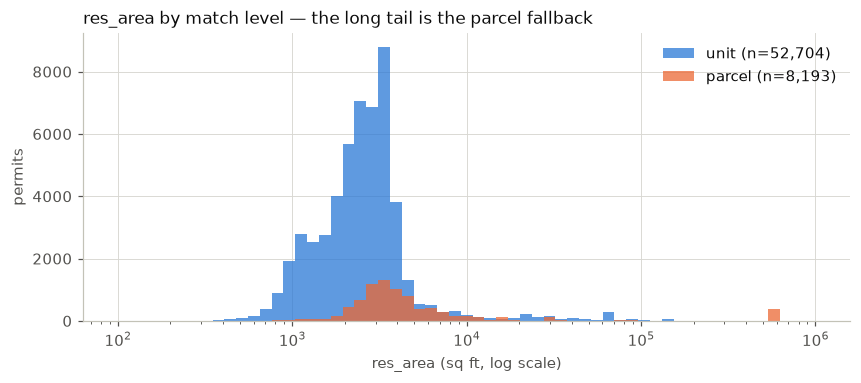

In [20]:
paired = [
    ("unit", BLUE),
    ("parcel", ORANGE),
]

fig, ax = plt.subplots(figsize=(9, 3.4))
bins = np.logspace(np.log10(100), np.log10(1_000_000), 60)
for level, color in paired:
    vals = df.loc[df["match_level"] == level, "res_area"]
    vals = vals[vals > 0]
    ax.hist(vals, bins=bins, color=color, alpha=0.75, label=f"{level} (n={len(vals):,})")
ax.set_xscale("log")
ax.set_title("res_area by match level — the long tail is the parcel fallback")
ax.set_xlabel("res_area (sq ft, log scale)")
ax.set_ylabel("permits")
ax.legend(frameon=False)
plt.show()

The orange distribution is shifted right and much wider — that is the aggregation, not
bad data. A `parcel` row reading 559,416 sq ft is a correct sum over 125 assessment
records; it is simply not a house.

**The practical consequence:** if you filter `res_area` on a single global threshold you
will delete the parcel rows almost exclusively, and with them most of the large
multi-family buildings. If what you want is "single-family-ish housing," filter on
`match_level` and `use_code` — the thing you actually mean — rather than on square footage.

## 5. Numeric distributions

One row per field: percentiles, a histogram, and the extreme rows. The percentile table
is the one to read — it tells you where a cutoff would land and how many rows sit past it.

In [21]:
DETAIL_COLS = ["address", "parcel_prefix", "match_level", "assess_records",
               "year_built", "res_area", "num_rooms", "stories", "use_code", "style"]

def review(col: str, *, log: bool = False, bins: int = 60, show: int = 6, clip=None):
    """Percentiles + histogram + the extreme rows for one numeric column."""
    s = df[col]
    valid = s.dropna()
    nonzero = valid[valid > 0]

    qs = [0, 0.001, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999, 1]
    table = pd.DataFrame({
        "all non-null": valid.quantile(qs).values,
        "non-null & > 0": nonzero.quantile(qs).values if len(nonzero) else np.nan,
    }, index=[f"p{q * 100:g}" for q in qs]).round(1)
    print(f"### {col}   n={len(valid):,}  null={s.isna().sum():,}  zero={(valid == 0).sum():,}")
    print(table.to_string())

    plot_vals = nonzero if log else valid
    if clip is not None:
        plot_vals = plot_vals[plot_vals.between(*clip)]
    fig, ax = plt.subplots(figsize=(9, 2.9))
    edges = (np.logspace(np.log10(max(plot_vals.min(), 1e-9)), np.log10(plot_vals.max()), bins)
             if log else bins)
    ax.hist(plot_vals, bins=edges, color=BLUE)
    if log:
        ax.set_xscale("log")
    ax.set_title(f"{col}" + (" (log scale, zeros dropped)" if log else "")
                 + (f" clipped to {clip}" if clip else ""))
    ax.set_ylabel("permits")
    plt.show()

    print(f"largest {show}:")
    print(df.nlargest(show, col)[DETAIL_COLS].to_string())
    print(f"\nsmallest {show} (non-null):")
    print(df.nsmallest(show, col)[DETAIL_COLS].to_string())

### year_built   n=61,214  null=836  zero=0
       all non-null  non-null & > 0
p0           1714.0          1714.0
p0.1         1800.0          1800.0
p1           1856.0          1856.0
p5           1885.0          1885.0
p25          1900.0          1900.0
p50          1900.0          1900.0
p75          1920.0          1920.0
p95          2003.0          2003.0
p99          2020.0          2020.0
p99.9        2023.0          2023.0
p100         2024.0          2024.0


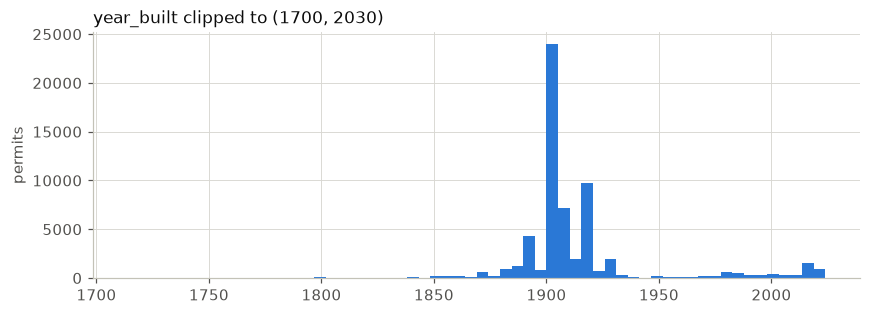

largest 6:
                                                     address parcel_prefix match_level  assess_records  year_built  res_area  num_rooms  stories use_code                style
389         325 ALEWIFE BROOK PKWY, SOMERVILLE MASSACHUSETTS        3-F-35      parcel             5.0      2024.0   11168.0       22.0      2.8     1040           Two Family
614                  16 MEDFORD ST, SOMERVILLE MASSACHUSETTS        97-E-4        unit             1.0      2024.0   50025.0        0.0      4.0     0112  Mid Rise Apartments
732                 21 GLENWOOD RD, SOMERVILLE MASSACHUSETTS       41-D-31        unit             1.0      2024.0    2144.0        9.0      2.0     1010           Two Family
758   325 ALEWIFE BROOK PKWY, SOMERVILLE MASSACHUSETTS 02144        3-F-35      parcel             5.0      2024.0   11168.0       22.0      2.8     1040           Two Family
1269           16 MEDFORD ST, SOMERVILLE MASSACHUSETTS 02143        97-E-4        unit             1.0      2024.0

In [22]:
review("year_built", clip=(1700, 2030))

`year_built` is the best-behaved field here. The floor at 1714 is a plausible-but-checkable
colonial date, the median of 1900 matches Somerville's streetcar-suburb build-out, and
there are no zero sentinels. The one caveat: on `parcel` rows this is a **median across
the building's units**, so a 2015 condo conversion inside an 1890 shell can land anywhere
in between.

Anything after the extract date, or before ~1630, would be a data error. Check the table
above; if the range is clean, this column needs no filter.

### res_area   n=61,377  null=673  zero=480
       all non-null  non-null & > 0
p0              0.0           125.0
p0.1            0.0           410.0
p1            528.8           726.0
p5            971.8          1005.0
p25          1863.0          1890.0
p50          2670.0          2686.0
p75          3456.0          3462.0
p95          8792.0          8842.0
p99         81950.0         81950.0
p99.9      559416.0        559416.0
p100       860111.0        860111.0


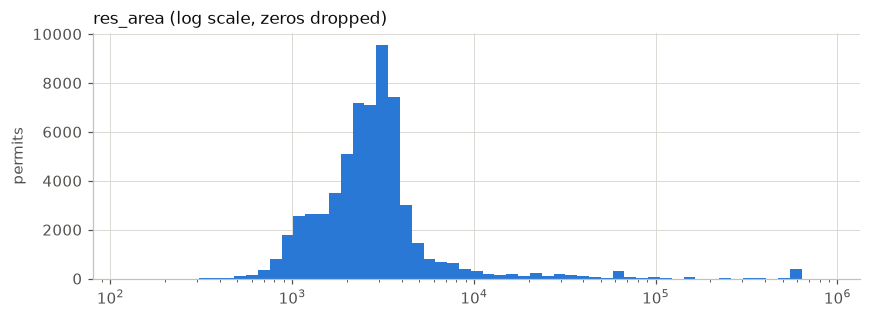

largest 6:
                                                 address parcel_prefix match_level  assess_records  year_built  res_area  num_rooms  stories use_code       style
7711   399 REVOLUTION DR, SOMERVILLE MASSACHUSETTS 02145        99-A-9      parcel             4.0      2015.0  860111.0        0.0     10.5     0336  Pkg Garage
20772             375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020    Mid rise
24263             375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020    Mid rise
24813             375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020    Mid rise
24814             375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020    Mid rise
24815            

In [23]:
review("res_area", log=True)

### num_rooms   n=61,448  null=602  zero=3,146
       all non-null  non-null & > 0
p0              0.0             1.0
p0.1            0.0             2.0
p1              0.0             3.0
p5              0.0             5.0
p25             7.0             8.0
p50            11.0            11.0
p75            14.0            14.0
p95            21.0            21.0
p99            76.5           115.0
p99.9         456.0           456.0
p100          456.0           456.0


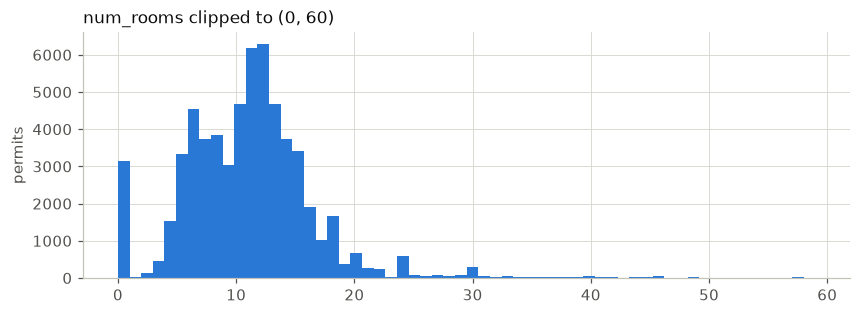

largest 6:
                                      address parcel_prefix match_level  assess_records  year_built  res_area  num_rooms  stories use_code     style
20772  375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020  Mid rise
24263  375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020  Mid rise
24813  375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020  Mid rise
24814  375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020  Mid rise
24815  375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020  Mid rise
25047  375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      20

In [24]:
review("num_rooms", clip=(0, 60))

### stories   n=45,012  null=17,038  zero=0
       all non-null  non-null & > 0
p0              1.0             1.0
p0.1            1.0             1.0
p1              1.5             1.5
p5              1.8             1.8
p25             2.3             2.3
p50             2.5             2.5
p75             2.8             2.8
p95             3.0             3.0
p99            12.0            12.0
p99.9          12.0            12.0
p100           24.0            24.0


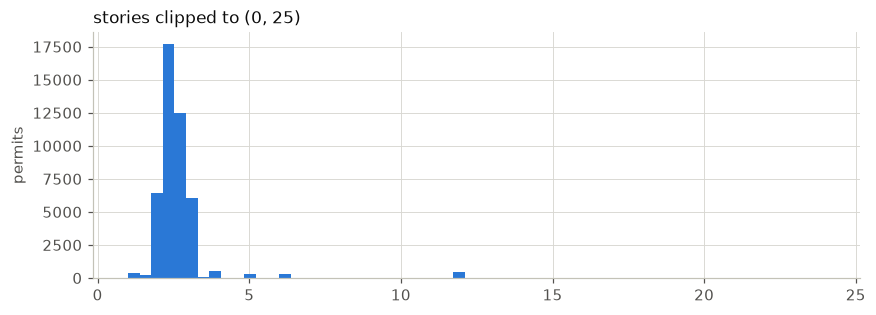

largest 6:
                                          address parcel_prefix match_level  assess_records  year_built  res_area  num_rooms  stories use_code          style
6656   301 ASSEMBLY ROW, SOMERVILLE MASSACHUSETTS       99-A-14        unit             1.0      2019.0  522542.0        0.0     24.0     0112  High Rise Apt
16326  301 ASSEMBLY ROW, SOMERVILLE MASSACHUSETTS       99-A-14        unit             1.0      2019.0  522542.0        0.0     24.0     0112  High Rise Apt
21630      485 FOLEY ST, SOMERVILLE MASSACHUSETTS       99-A-14        unit             1.0      2019.0  522542.0        0.0     24.0     0112  High Rise Apt
30606      485 FOLEY ST, SOMERVILLE MASSACHUSETTS       99-A-14        unit             1.0      2019.0  522542.0        0.0     24.0     0112  High Rise Apt
54536  301 ASSEMBLY ROW, SOMERVILLE MASSACHUSETTS       99-A-14        unit             1.0      2019.0  522542.0        0.0     24.0     0112  High Rise Apt
3747   301 CANAL STREET, SOMERVILLE MASSA

In [25]:
review("stories", clip=(0, 25))

### assess_records   n=61,451  null=599  zero=0
       all non-null  non-null & > 0
p0              1.0             1.0
p0.1            1.0             1.0
p1              1.0             1.0
p5              1.0             1.0
p25             1.0             1.0
p50             1.0             1.0
p75             1.0             1.0
p95             3.0             3.0
p99            20.0            20.0
p99.9         125.0           125.0
p100          125.0           125.0


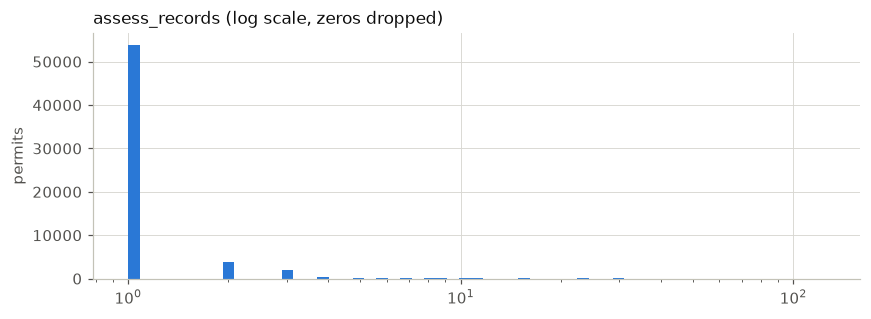

largest 6:
                                      address parcel_prefix match_level  assess_records  year_built  res_area  num_rooms  stories use_code     style
20772  375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020  Mid rise
24263  375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020  Mid rise
24813  375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020  Mid rise
24814  375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020  Mid rise
24815  375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020  Mid rise
25047  375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      20

In [26]:
review("assess_records", log=True)

`assess_records` is the count of assessment rows folded into the attributes on that
permit, and it is the cleanest single **flag for how much to trust a row**:

- `1` — one building, attributes are literal.
- `2`–`5` — a two- or three-family, totals are still interpretable as a building.
- `>20` — a large condo or apartment block. `res_area` and `num_rooms` are building sums
  and `year_built`/`stories` are medians over dozens of units.

It is a better filter key than `res_area` because it says *why* a row is large.

61,976 rows with coordinates; 0 outside the Somerville bbox


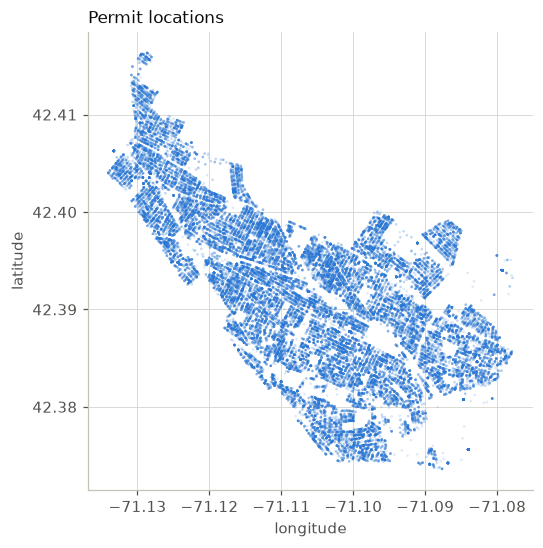

In [27]:
# Geography: everything should sit inside Somerville's bounding box.
SOM_BBOX = dict(lat=(42.37, 42.42), lon=(-71.14, -71.07))

geo = df.dropna(subset=["latitude", "longitude"])
outside = geo[
    ~geo["latitude"].between(*SOM_BBOX["lat"]) | ~geo["longitude"].between(*SOM_BBOX["lon"])
]
print(f"{len(geo):,} rows with coordinates; {len(outside):,} outside the Somerville bbox")

fig, ax = plt.subplots(figsize=(6.4, 5.4))
ax.scatter(geo["longitude"], geo["latitude"], s=3, alpha=0.15,
           color=BLUE, edgecolors="none", label=f"in bbox (n={len(geo) - len(outside):,})")
if len(outside):
    ax.scatter(outside["longitude"], outside["latitude"], s=26, color=ORANGE,
               edgecolors="white", linewidths=0.5, label=f"outside (n={len(outside):,})")
    ax.legend(frameon=False, loc="best")
ax.set_title("Permit locations")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_aspect(1 / np.cos(np.radians(42.39)))
plt.show()

if len(outside):
    print(outside[["address", "latitude", "longitude", "apn"]].head(10).to_string())

A dense city-shaped blob with no scattered points means geocoding is sound and
`latitude`/`longitude` need no filtering. Stray points are almost always a null island
(0, 0) or a state-plane coordinate that escaped conversion — both obvious in the scatter.

## 6. Filter workbench

Everything above was diagnosis. This is the part to actually turn the dials on.

Each rule below is a named boolean mask. The cells that follow report, for a given
`PARAMS`: how many rows each rule costs, how much the rules overlap, and — the important
one — **whether any rule falls disproportionately on one project type**. A filter that
quietly removes a third of your `solar_pv` rows has changed the answer, not cleaned the data.

The defaults are deliberately conservative: they flag records that are *structurally
unusable* (no assessor match, sentinel zeros) and leave the big-building rows alone, since
section 4 showed those are correct aggregates rather than errors.

In [28]:
PARAMS = dict(
    # --- structural: the row can't support attribute-level analysis ---
    require_assessor_match = True,   # drop match_level.isna()
    require_res_area       = True,   # drop res_area == 0 (assessor sentinel)
    require_year_built     = True,   # drop year_built.isna()

    # --- scope: what counts as a "building" for your question ---
    max_assess_records     = None,   # e.g. 5 to keep 1-3 family; None = keep all
    unit_matches_only      = False,  # True = drop the parcel-level aggregates entirely

    # --- value ranges ---
    year_built_range       = (1630, 2027),
    res_area_range         = (200, None),      # None = no upper bound
    num_rooms_max          = None,             # e.g. 30

    # --- date coverage ---
    date_range             = (None, None),     # e.g. ("2015-01-01", "2025-12-31")

    # --- geography ---
    require_in_bbox        = True,
)

In [29]:
def build_rules(frame: pd.DataFrame, p: dict) -> dict[str, pd.Series]:
    """Each entry is a mask of rows the rule would REMOVE. Disabled rules are omitted."""
    r: dict[str, pd.Series] = {}
    f = lambda: pd.Series(False, index=frame.index)  # noqa: E731

    if p["require_assessor_match"]:
        r["no assessor match"] = frame["match_level"].isna()
    if p["require_res_area"]:
        r["res_area == 0 (sentinel)"] = frame["res_area"].eq(0)
    if p["require_year_built"]:
        r["year_built missing"] = frame["year_built"].isna()

    if p["max_assess_records"] is not None:
        r[f"assess_records > {p['max_assess_records']}"] = (
            frame["assess_records"] > p["max_assess_records"]
        ).fillna(False)
    if p["unit_matches_only"]:
        r["parcel-level aggregate"] = frame["match_level"].eq("parcel")

    lo, hi = p["year_built_range"]
    if lo is not None or hi is not None:
        m = f()
        if lo is not None:
            m |= frame["year_built"].lt(lo).fillna(False)
        if hi is not None:
            m |= frame["year_built"].gt(hi).fillna(False)
        r[f"year_built outside {p['year_built_range']}"] = m

    lo, hi = p["res_area_range"]
    if lo is not None or hi is not None:
        m = f()
        if lo is not None:
            m |= frame["res_area"].lt(lo).fillna(False) & frame["res_area"].ne(0)
        if hi is not None:
            m |= frame["res_area"].gt(hi).fillna(False)
        r[f"res_area outside {p['res_area_range']}"] = m

    if p["num_rooms_max"] is not None:
        r[f"num_rooms > {p['num_rooms_max']}"] = frame["num_rooms"].gt(p["num_rooms_max"]).fillna(False)

    lo, hi = p["date_range"]
    if lo is not None or hi is not None:
        m = f()
        if lo is not None:
            m |= frame["application_date"] < pd.Timestamp(lo)
        if hi is not None:
            m |= frame["application_date"] > pd.Timestamp(hi)
        r[f"date outside {p['date_range']}"] = m

    if p["require_in_bbox"]:
        r["lat/lon missing or outside bbox"] = ~(
            frame["latitude"].between(*SOM_BBOX["lat"])
            & frame["longitude"].between(*SOM_BBOX["lon"])
        ).fillna(False)

    return r


rules = build_rules(df, PARAMS)
dropped = pd.DataFrame(rules)
any_dropped = dropped.any(axis=1)

cost = pd.DataFrame({
    "rows flagged": dropped.sum(),
    "% of table": (dropped.mean() * 100).round(2),
    "flagged by this rule ONLY": [
        int((dropped[c] & (dropped.sum(axis=1) == 1)).sum()) for c in dropped
    ],
}).sort_values("rows flagged", ascending=False)

print(f"{any_dropped.sum():,} of {len(df):,} rows flagged "
      f"({any_dropped.mean() * 100:.2f}%) -> {(~any_dropped).sum():,} kept\n")
cost

1,187 of 62,050 rows flagged (1.91%) -> 60,863 kept



,rows flagged,% of table,flagged by this rule ONLY
year_built missing,836,1.35,92
no assessor match,599,0.97,0
res_area == 0 (sentinel),480,0.77,335
lat/lon missing or outside bbox,74,0.12,15
"res_area outside (200, None)",1,0.00,1
"year_built outside (1630, 2027)",0,0.00,0


Read the **`flagged by this rule ONLY`** column against `rows flagged`. A rule whose two
numbers are close is doing independent work. A rule whose "only" count is near zero is
redundant — it is catching rows another rule already caught, and you can drop it from
`PARAMS` without changing the output.

In [30]:
# Does any rule land disproportionately on one project type? This is the question that
# decides whether a filter is cleaning data or biasing the result.
# The flags overlap, so there is no "share of total" to compare -- a row can sit in two
# rows of this table. The comparable quantity is each flag's own removal rate against
# the overall rate.
overall = any_dropped.mean() * 100

rows = {}
for label in [*FLAGS, "untagged"]:
    mask = (n_flags == 0) if label == "untagged" else df[label]
    before = int(mask.sum())
    after = int((mask & ~any_dropped).sum())
    rows[label] = {
        "before": before,
        "after": after,
        "removed": before - after,
        "removed_%": round((before - after) / before * 100, 2) if before else np.nan,
    }
summary = pd.DataFrame(rows).T
summary["vs overall (pp)"] = (summary["removed_%"] - overall).round(2)
print(f"overall removal rate: {overall:.2f}%")
summary.sort_values("removed_%", ascending=False)

overall removal rate: 1.91%


,before,after,removed,removed_%,vs overall (pp)
untagged,48923.0,47919.0,1004.0,2.05,0.14
ev_charger,318.0,312.0,6.0,1.89,-0.02
other_hvac,6001.0,5900.0,101.0,1.68,-0.23
electrical_panel,3383.0,3338.0,45.0,1.33,-0.58
heat_pumps,1503.0,1486.0,17.0,1.13,-0.78
solar_pv,2380.0,2360.0,20.0,0.84,-1.07


The column to watch is **`vs overall (pp)`** - each flag's removal rate minus the overall
rate, in percentage points. Near zero everywhere means the filter is neutral with respect
to project type and you have genuinely cleaned data.

A flag several points above the overall rate means the filter is **correlated with the
thing you are trying to measure**, and the usual cause is building type: solar and EV
work concentrate in owner-occupied single-families, while the structural rules bite
hardest on condo records (see the `year_built` note below). Removing rows on a criterion
that tracks your outcome variable biases the result no matter how defensible the
criterion looks in isolation.

Rates here do not sum to the overall rate and are not meant to - a multi-flag row is
counted in every row of the table it belongs to.

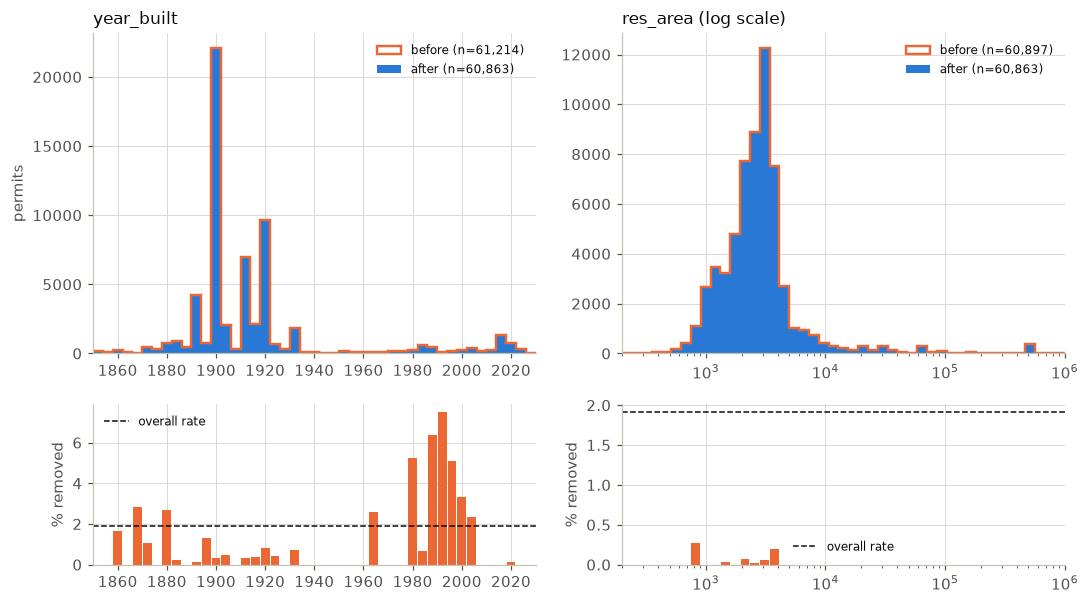

In [31]:
# Where in each distribution do the removals land? A filter that is safe removes rows
# evenly across the range; one that is biased eats a specific part of it.
#
# Top row: the kept distribution (fill) with the full distribution as an outline -- an
# outline can't be hidden underneath, which a second filled histogram would be.
# Bottom row: removal rate per bin, which is the actual question.
SPECS = [
    ("year_built", np.linspace(1850, 2030, 46), False),
    ("res_area", np.logspace(np.log10(200), np.log10(1_000_000), 46), True),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 5.6), height_ratios=[2, 1])
for (col, bins, log), top, bot in zip(SPECS, axes[0], axes[1]):
    before = df[col]
    after = df.loc[~any_dropped, col]
    if log:
        before, after = before[before > 0], after[after > 0]

    top.hist(before, bins=bins, histtype="step", color=ORANGE,
             linewidth=1.6, label=f"before (n={before.notna().sum():,})")
    top.hist(after, bins=bins, color=BLUE, label=f"after (n={after.notna().sum():,})")
    top.set_title(col + (" (log scale)" if log else ""))
    top.legend(frameon=False, fontsize=8)

    n_before, _ = np.histogram(before.dropna(), bins=bins)
    n_after, _ = np.histogram(after.dropna(), bins=bins)
    with np.errstate(invalid="ignore", divide="ignore"):
        rate = np.where(n_before > 0, (n_before - n_after) / n_before * 100, np.nan)
    centers = (bins[:-1] + bins[1:]) / 2
    bot.bar(centers, rate, width=np.diff(bins) * 0.9, color=ORANGE)
    bot.axhline(any_dropped.mean() * 100, color=INK, linewidth=1,
                linestyle="--", label="overall rate")
    bot.set_ylabel("% removed")
    bot.legend(frameon=False, fontsize=8)

    for ax in (top, bot):
        if log:
            ax.set_xscale("log")
        ax.set_xlim(bins[0], bins[-1])

axes[0][0].set_ylabel("permits")
fig.tight_layout()
plt.show()

**Reading the bottom row.** The dashed line is the overall removal rate; bars above it are
parts of the distribution the filter hits harder than average.

With the conservative defaults, `res_area` removal is flat and near zero -- no size-based
bias. `year_built` is not flat: removals concentrate in the **1980-2005** band at roughly
4x the overall rate. Worth understanding before you accept it. In that band the removals
come from exactly one rule -- `res_area == 0` (3.3% of the band vs 0.77% overall) -- and
those rows are almost entirely `use_code` 995, `style` "Condominium". Not join failures:
`match_level` is never null in that band. It is the assessor writing a zero-area record
for condo units built in the conversion era.

So the "structural, obviously-safe" `res_area == 0` rule is not uniform -- it is
concentrated on **condominium stock from a specific 25-year window**.

If your question is about older single- and two-family housing, that is harmless. If it
touches condos or recent construction, this default is quietly thinning your subject
population, and you would rather keep those rows and handle the zero some other way --
treat it as NA and impute, or use an analysis that doesn't need `res_area`.

Re-run this section with `require_res_area = False` to see the difference.

In [32]:
# The rows you are about to throw away. Read this before you commit to the thresholds --
# if these look like permits you care about, the thresholds are wrong.
SHOW_RULE = None   # e.g. "no assessor match"; None = a sample across all flagged rows

pool = df[dropped[SHOW_RULE]] if SHOW_RULE else df[any_dropped]
print(f"{len(pool):,} rows flagged by {SHOW_RULE or 'any rule'}\n")
pool.sample(min(15, len(pool)), random_state=0)[
    ["application_date", "application_type", "flag_label", "project_description",
     "address", "match_level", "assess_records", "year_built", "res_area", "num_rooms"]
]

1,187 rows flagged by any rule



,application_date,application_type,flag_label,project_description,address,match_level,assess_records,year_built,res_area,num_rooms
43704,2025-07-14,Electrical Permit,untagged,Whole new house wiring,"0 RICHARDSON ST, SOMERVILLE MASSACHUSETTS",unit,1.0,NaN,0.0,0.0
29694,2017-04-28,Electrical Permit,other_hvac,Wire garage and a/c units,"35 CUTTER ST, SOMERVILLE MASSACHUSETTS 02145",parcel,2.0,NaN,3926.0,14.0
46682,2019-02-21,Electrical Permit,untagged,Installation of audio/video equipment PH114,"375A CANAL ST, SOMERVILLE MASSACHUSETTS",NaN,NaN,NaN,NaN,NaN
59533,2020-10-09,Building Permit,untagged,Remove and replace existing Kitchen Cabinets. Remove bathroom tub and install a walkin...,"25 WARREN AVE, SOMERVILLE MASSACHUSETTS",NaN,NaN,NaN,NaN,NaN
19342,2026-04-07,Building Permit,untagged,"Construct a new 3-unit house ground up, in a NR district, with a total of 5462 sf of l...","10 OAK ST, SOMERVILLE MASSACHUSETTS 02143",unit,1.0,NaN,0.0,0.0
26666,2024-12-30,Building Permit,untagged,Skylight replacement,"44 PORTER ST, SOMERVILLE MASSACHUSETTS 02143",unit,1.0,1880.0,0.0,0.0
34526,2017-10-11,Plumbing Permit,untagged,replacement,"91 SUMMER ST, SOMERVILLE MASSACHUSETTS 02143",unit,1.0,1900.0,0.0,0.0
23432,2016-08-15,Gas Fitting,untagged,Replacement of the gas stove.,"36R OTIS ST, SOMERVILLE MASSACHUSETTS",NaN,NaN,NaN,NaN,NaN
46534,2019-02-19,Electrical Permit,untagged,Unit 55 - wire a bath and kitchen remodel job,"433 BROADWAY, SOMERVILLE MASSACHUSETTS 02145",NaN,NaN,NaN,NaN,NaN
51184,2019-09-05,Electrical Permit,other_hvac,Wire 2 A/C replacement and 2 furnace replacement,"212 POWDER HOUSE BLVD, SOMERVILLE MASSACHUSETTS",unit,1.0,1910.0,0.0,0.0


## 7. The filtered table

Once the numbers above look right, this is the frame to carry forward. It is written back
out next to the pipeline output rather than replacing it, so the unfiltered table stays
the source of truth and this decision stays reversible.

In [33]:
clean = df[~any_dropped].copy()

print(f"kept {len(clean):,} of {len(df):,} rows ({len(clean) / len(df) * 100:.2f}%)")
print(f"date range: {clean['application_date'].min():%Y-%m-%d} to {clean['application_date'].max():%Y-%m-%d}")
print(f"assessor match: {clean['match_level'].notna().mean() * 100:.1f}%\n")
print("Active rules:")
for name in cost.index:
    print(f"  - {name}: -{cost.loc[name, 'rows flagged']:,}")
clean.describe(include="all").T

kept 60,863 of 62,050 rows (98.09%)
date range: 2014-02-13 to 2026-09-03
assessor match: 100.0%

Active rules:
  - year_built missing: -836
  - no assessor match: -599
  - res_area == 0 (sentinel): -480
  - lat/lon missing or outside bbox: -74
  - res_area outside (200, None): -1
  - year_built outside (1630, 2027): -0


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
application_number,60863,60863,E14-001179,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
application_date,60857,NaN,NaN,NaN,2020-04-29 19:05:45.761375,2014-02-13 00:00:00,2017-03-29 00:00:00,2020-01-22 00:00:00,2023-06-12 00:00:00,2026-09-03 00:00:00,NaN
application_type,60863,4,Building Permit,24551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
application_subtype,60863,9,Residential,18031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
project_description,60845,49667,Replace Water Heater,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN
solar_pv,60863,2,False,58503,NaN,NaN,NaN,NaN,NaN,NaN,NaN
heat_pumps,60863,2,False,59377,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ev_charger,60863,2,False,60551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
electrical_panel,60863,2,False,57525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
other_hvac,60863,2,False,54963,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
# Uncomment when the thresholds are settled. If these rules become permanent,
# move them into scripts/process_somerville_data.py so the pipeline output is
# the filtered table and this notebook goes back to being a check on it.

# OUT = Path("../data/processed/ma/somerville/joined_data_filtered.csv")
# clean.to_csv(OUT, index=False)
# print(f"wrote {len(clean):,} rows to {OUT}")